***Documentation:***
- https://medium.com/data-science/lets-code-convolutional-neural-network-in-plain-numpy-ce48e732f5d5
- https://medium.com/thedeephub/convolutional-neural-networks-a-comprehensive-guide-5cc0b5eae175
- https://medium.com/analytics-vidhya/introduction-to-long-short-term-memory-lstm-a8052cd0d4cd
- https://medium.com/@RaghavPrabhu/understanding-of-convolutional-neural-network-cnn-deep-learning-99760835f148
- https://www.datacamp.com/tutorial/introduction-to-convolutional-neural-networks-cnns
- https://www.superannotate.com/blog/guide-to-neural-networks-and-deep-learning
- https://medium.com/@khalid.preneurlab07/neural-networks-vs-convolutional-neural-networks-whats-the-difference-f6e7363aff35
- https://medium.com/@saba99/receptive-field-1726fe6ea94f
- https://www.geeksforgeeks.org/deep-learning/cnn-introduction-to-pooling-layer/
- https://medium.com/@nikitamalviya/convolution-pooling-f8e797898cf9

__________________________________
## **Introduction: A Cnn from scratch, why ?**


![Eye](assets/Image.jpg)

## **Introduction**

Nowadays libraries like pytorch, TensorFlow, Keras.. etc have greatly simplified the implementation of AI models.
However, the solid understanding of what is happening "inside" a Neural Network helps a lot with tasks like architecture selection, hyperparameters tuning but also in optimizing performances.

### **What is a CNN ?**

Convolutional Neural Networks (CNNs) are a type of deep learning AI Models (Well, Neural Networks!) that mainly helps computers **"see"** and **"understand"** images by learning patterns.

CNNs work by applying mathematical operations to extract meaningful features (such as edges, textures, and shapes from images.)

CNNs are widely used for image-related tasks like classification, object detection, segmentation and video analysis. Beyond that, CNNs help in medical imaging, satellite imagery, gesture recognition..etc


### **Our data!**

Since CNNs are used to process images, let’s first understand what an *image* actually is.  

An image is essentially a **matrix of numbers** where each number corresponds to a pixel

![Image](assets/Explanation.webp)

Each number holds information about how each pixel should look -its brightness or color-

That's why we talk about applying mathematical equations, because we need linear algebra to manipulate matrices.

![Image](assets/Matrice.png)

For RGB images (which use the Red, Green, and Blue color channels), we have one matrix for each channel. When these three matrices are combined, they form the final colored image.
For gray Scale images (which use black, white, or any shade of gray in between) we have one matrix




In linear algebra, these matrices are called **tensors**, they usually have the shape (height, width, number of channels):

In [57]:
from matplotlib import image

img = image.imread('./assets/Sample.png')
print(img.shape)


(668, 924, 3)


________________________________________

## **But what EVEN is a Neural Network ?**

Let's rewind a bit! We said that CNNs are Neural Networks
*A good understanding of CNNs requires a good understanding of Neural Networks!*

The most basic unit in a neural network is a neuron (refering to a human brain neuron) a so-called **percpetron**.

Let's understand how it works by taking a real life example!

Here's an example of a perceptron that helps you decide whether to take an umbrella or not tomorrow based on some informations (inputs).
We have two inputs:

- x1: Is the sky cloudy? (1 = yes, 0 = no)

- x2: ​Is the weather forecast saying rain? (1 = yes, 0 = no)


In [58]:
import numpy as np

x = np.array([1, 0])  #cloudy but forecast says it's not gonna rain (1 for cloudy, 0 for weatherforecast)


**Now**, how does it know which factor matters more? 
That’s where weights come in!
**Weights** are numbers that tell the neuron how important each input is, perhaps we should trust the weather forecast more than our own observations of the sky ? So we give it more importance, a greater weight!

In [59]:
weights = np.array([0.4, 0.6])

Another concept is the bias, think of it as your **"personal tendency"**

- If you usually take an umbrella, even when it’s just a bit cloudy → your bias is positive (you’re more easily convinced).
- If you usually don’t, unless it’s definitely going to rain → your bias is negative (you need stronger evidence).

In [60]:

bias = 0.2

Now, to decide whether or not to take the umbrella, you multiply your inputs by their weights, sum them up, and then add your bias!

In [61]:

z = np.dot(x, weights) + bias

If the combined score (we call it z) is high enough, the neuron outputs 1 → Take the umbrella!
If not, it outputs 0 → No need.

When we say high enough, we're talking about a certain limit, a **Threshold**, if z is greater than that threshold, the answer is yes, otherwise no.

We call this process the **"activation function"**.
The simplest form is:

![Image](assets/Activation%20Function.png)

There is multiple other activation functions, but we'll settle with this one for now.



In [62]:
output = 1 if z > 0 else 0

print("Should I bring an umbrella?\n", "Yes ☔" if output == 1 else "No 🌤️")


Should I bring an umbrella?
 Yes ☔


We call this whole process (computing the output from inputs, weights, bias, and activation function) a **"forward propagation"**


![Image](assets/Perceptron.png)

In [63]:
def activation_function(z):
    return 1 if z > 0 else 0

def forward_pass(inputs, weights, bias, activation_function):
    z = np.dot(inputs, weights) + bias
    return activation_function(z)


Now, to build a neural network, we simply group multiple perceptrons into layers
The outputs from the first layer become the inputs for the next one.


Any layers between the input layer and the output layer are called hidden layers because they don’t directly “see” the input features or the final outputs.

![Image](assets/NeuralNetwork.png)



Now, let’s assume we already have some real data **y**, the **ACTUAL ACCURATE** weather prediction for the next 7 days!

In [64]:
# Real data (1 = its gonna rain, so take your umbrella, 0 = it's not gonna rain, so don't take it)
y = np.array([0, 0, 0, 0, 1, 0, 0])  

X = np.array([
    [0, 1],  # cloudy only → 0
    [0, 1],  # cloudy only → 0
    [1, 0],  # sunny only → 0
    [0, 0],  # neither → 0
    [1, 1],  # sunny + cloudy → 1
    [0, 0],  # neither → 0
    [1, 0]   # sunny only → 0
])


output = forward_pass(X[0], weights, bias, activation_function) #Test the first day
print("Should I bring an umbrella?\n", "Yes ☔" if output == 1 else "No 🌤️")



Should I bring an umbrella?
 Yes ☔


We see that our model predicted that we should bring our umbrella because it's gonna rain, but the real data says it won’t.
This means we need to adjust our weights and bias to improve the prediction!


The difference between the predicted value and the actual value is called the **error**

- **error = real_value − predicted_value**

The goal is to minimize this error as much as possible, the process of adjusting weights based on the error is called **backward propagation** (or backpropagation).

In [65]:
def back_propagation(X, y, weights, bias, learning_rate):
    for i in range(len(X)):
        prediction = forward_pass(X[i], weights, bias, activation_function)
        error = y[i] - prediction
        
        weights += learning_rate * error * X[i]
        bias += learning_rate * error
    return weights, bias

We introduced a new parameter called the learning_rate, it's a small number that controls how much we adjust the weights and bias during backpropagation.

- A small learning rate makes learning slow but stable.
- A large learning ratespeeds up learning but can cause the model to overshoot and miss the optimal solution.


A single pass often isn’t enough for the model to learn patterns.
By going through the data many times, the model gradually adjusts its weights to reduce error and improve predictions, that's where we introduce the parameter "epoch" (basically iterations through the dataset)

In [66]:
def training(X, y, weights, bias, learning_rate, epochs):
    for epoch in range(epochs):
        weights, bias = back_propagation(X, y, weights, bias, learning_rate)
    return weights, bias

weights, bias = training(X, y, weights, bias, learning_rate=0.5, epochs=20)

output = [forward_pass(X[i], weights, bias, activation_function) for i in range(len(X))]
print("Predictions after training:", output)


Predictions after training: [0, 0, 0, 0, 1, 0, 0]


Nice! Our model is now trained! Now that we got the basics of neural networks, let's go back to CNNs! 


_____________________________

### **Now we are ready to understand convolutional neural networks!**

But first, what makes a CNN different from a basic neural network?

### **1 - Weight Sharing**

- In NNs, Every connection has its own weight
- In CNNs, a "filter" is applied across different parts of the input (the Image), It’s like applying several weights at once.

At each position, the filter is element-wise **multiplied** with the corresponding portion of the image.


*A filter is a small matrix of numbers (weights) that we slide over the image. It applies a transformation to the image matrice, which allows us to detect patterns (such as edges, textures, shapes..)*
***The filter is like a stamp or a template. If the part of the image looks like the stamp, the result is high (the number you get after applying the filter is large and not a lot of numbers cancel out), showing that feature is present. This Operation is Called Convolution***


![Image](assets/Kernel.png)


**Technically** we CAN assign a separate weight to every pixel of the image like a normal NN does, but it becomes very inefficient when images gets bigger.


C:\Users\Bleu\AppData\Local\Temp\ipykernel_14660\1876625186.py:19: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imread("./assets/Sample.png")


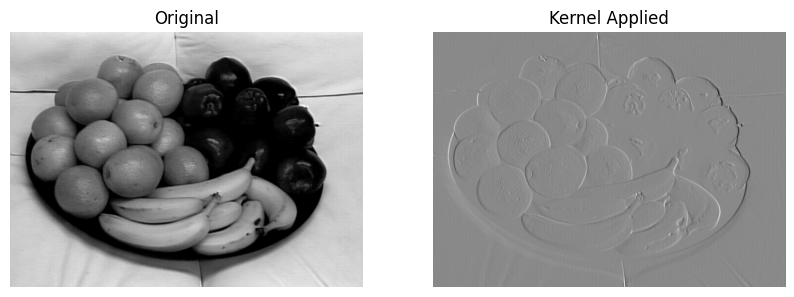

In [73]:
import numpy as np
from imageio import imread  
import matplotlib.pyplot as plt

def convolution(image, kernel):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape
    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1
    output = np.zeros((output_height, output_width))
    
    for i in range(output_height):
        for j in range(output_width):
            region = image[i:i+kernel_height, j:j+kernel_width]
            output[i, j] = np.sum(region * kernel)
    
    return output

image = imread("./assets/Sample.png")

if image.ndim == 3:  
    image_gray = 0.299*image[:,:,0] + 0.587*image[:,:,1] + 0.114*image[:,:,2]
else:
    image_gray = image

# A simple intense kernel for edge detection
kernel = np.array([[1, -1],
                   [1, -1]])  

filtered_image = convolution(image_gray, kernel)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image_gray, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(filtered_image, cmap='gray')
plt.title("Kernel Applied")
plt.axis('off')

plt.show()



*The numbers 0.299, 0.587, 0.114 are from the luminosity "method"*


*Basically, A gray pixel has the same value for R, G, and B.*

*Black → (0, 0, 0)*

*White → (255, 255, 255)*

*Medium gray → (128, 128, 128)*


*So gray is just a color where R = G = B.*
*The human eye doesn’t treat red, green, and blue equally.*
*Green looks brightest to us, Red is less bright than green, and Blue is the least bright.*
*And to get gray, we take a weighted sum instead of a simple average*


### **2 - Architecture**

- In NNs, every neuron in one layer connects to every neuron in the next layer
- In CNNs, we use local connections, each neuron connects only to a small region of the previous layer aka **a receptive field**.

![Image](assets/NnVSCnn.png)


Let's talk about the **receptive field** more

The receptive field refers to the region of the input image that a particular neuron is “looking at”


Let's start small: Imagine your input image is 7×7 pixels. You have a 3×3 filter in your first layer.
**Each neuron in this layer looks at just a 3×3 patch of the image**

So the **receptive field of that neuron is 3×3**.

![Image](assets/receptiveField.png)




___

# **CNN LAYERS**

Now that we know the global difference between NNs and CNNs, let's dive deeper into CNNS!

CNNs are composed of three key types of layers:

## 1. **Convolutional Layer:**
We talked about the convolution operation early on! In the convolution layer, several filters of equal size are applied, and each filter is used to recognize a specific pattern from the image
As the filter slides across the input, it creates a new grid/matrice called the **feature map**.


steps:

**1- Place the kernel on the top-left corner of the image.**

**2- Multiply each element of the kernel by the corresponding element of the image under it**

**3- Sum all the products, and that becomes the first number in the output matrix.**

**4- Move the kernel one step to the right, repeat multiplication & sum**.

So basically, After a convolution layer, you get feature maps: big matrices where each number shows how strongly a pattern is present at different locations.



![Image](assets/Convolutions.gif)

In [1]:
def convolutional_layer(input_image, filters):
    feature_maps = []
    for kernel in filters:
        feature_map = convolution(input_image, kernel)
        feature_maps.append(feature_map)
    return np.array(feature_maps)

It’s simple, right?

But sometimes it’s a bit more complicated than that. To speed up calculations, a layer usually processes multiple images at once. So, we pass a 4D tensor with shape [n, h, w, c]:
 
- n = number of images in the batch

- h, w = height and width of each image

- c = number of channels

***Why is it possible?***

It's because matrix operations (like convolution and fully connected layers) can be done in parallel.
That's why instead of feeding one image at a time into the CNN, we feed a batch of n images together.
Linear Algebra is amazing!

In [3]:
def convolutional_layers(input_image, filters_list, batch_size=1):
    output = input_image
    for filters in filters_list:
        output = convolutional_layer(output, filters)
    return output

**Mathematical Representation:**

For an input image ‘X’ and a filter ‘W’, the convolution operation can be represented as:

![Image](assets/Convolution_Math.png)

Where:
- Y[i,j] is the feature map (our output)
- X is the input image,
- W is the filter applied over the image,
- m,n are the dimensions of the filter.


_______________________

## 2. **Pooling Layer:** 

*"Many believe higher resolution means better photos, smooth edges look pleasing to the eye. Yet, more pixels don’t always improve how computers interpret images. This redundancy, called over-representation, means even reducing tensor size often doesn’t harm prediction quality."*


The goal of the pooling layer is to reduce the dimensionality of the feature maps (aka make the convolution layer output SMALLER in size, which helps reduce computations.).
IT takes each feature map and shrinks it, keeping the most important information while discarding less important details.

**There is two steps:**

1 - Sliding Window:

   - A small window (usually 2x2 or 3x3) slides over the feature map.   
   - At each position, the window captures a region of the feature map.

    
2 - Pooling:

There is Many types of pooling, let's cite two! 

- **Max Pooling**: Within the window, the max pooling layer selects the maximum value (This  value represents the most important feature in that region)  

- **Average Pooling**: For each small region, take the average of all values.

![Image](assets/Pooling.gif)


In [2]:
def max_pooling(feature_map, pool_size, stride):
    input_height, input_width = feature_map.shape
    output_height = (input_height - pool_size) // stride + 1
    output_width = (input_width - pool_size) // stride + 1
    pooled_feature_map = np.zeros((output_height, output_width))
    
    for i in range(output_height):
        for j in range(output_width):
            region = feature_map[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            pooled_feature_map[i, j] = np.max(region)
    
    return pooled_feature_map

def average_pooling(feature_map, pool_size, stride):
    input_height, input_width = feature_map.shape
    output_height = (input_height - pool_size) // stride + 1
    output_width = (input_width - pool_size) // stride + 1
    pooled_feature_map = np.zeros((output_height, output_width))
    
    for i in range(output_height):
        for j in range(output_width):
            region = feature_map[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            pooled_feature_map[i, j] = np.mean(region)
    
    return pooled_feature_map

*You might ask: what’s the reason behind this?*

When we use a CNN to detect objects in an image, it’s important to understand that **it doesn’t actually know what an object is**. It only looks at the numbers in the feature map (the output of the convolution layer)

These numbers are called activations, and they represent how strongly a certain pattern (such as an edge, corner, or a texture that exists in that region)

So the pooling layer job is to "summarize the information" a small region like “Oh, look, there’s something important here, let’s keep that.”

In [ ]:
def pooling_layer(feature_maps, pool_size, stride, mode='max'):
    pooled_maps = []
    for feature_map in feature_maps:
        if mode == 'max':
            pooled_map = max_pooling(feature_map, pool_size, stride)
        elif mode == 'average':
            pooled_map = average_pooling(feature_map, pool_size, stride)
        pooled_maps.append(pooled_map)
    return np.array(pooled_maps)

Before jumping to the last layer, we go through the flattening step.

It’s one of the simplest yet most crucial operations in our model. it converts the multidimensional tensor into a one-dimensional vector (aka flattens the input). 
 
This is necessary because the next layer (the fully connected layers) expect a 1D vector as input.

![Image](assets/Flatten.png)



In [ ]:
def flatten(feature_maps):
    return feature_maps.flatten()

    
## 3. **Fully Connected Layer:**

Just like the neural networks we discussed earlier, this part of the model behaves exactly like fully connected layeers, and it will handle the prediction/detection.

Previously, we mentioned activation functions, which decide whether a neuron should "fire" or not based on its input. 

A commonly used activation in CNNs fully connected layers is **ReLU (Rectified Linear Unit)**. It outputs 0 for negative inputs and keeps positive inputs unchanged.

![Image](assets/Relu.png)

To understand why we use ReLU, 
We need first to understand a concept called non linearity: non-linearity means the network can learn complex relationships between inputs and outputs, relationships that aren’t just "straight lines"

Imagine you have a plot of points representing cats and dogs in a dataset.

![Image](assets/Pattern.png)


If the network could only draw straight lines, it could only separate points that are neatly divided in a line, but cats and dogs are often mixed in complicated ways.
So Non-linear activation functions like ReLU let the network create curved boundaries so it can separate cats from dogs correctly.

In [ ]:
def Relu(x):
    return np.maximum(0, x)

In [ ]:
def connected_layer(input_array, weights, bias, activation_function):
    z = np.dot(input_array.flatten(), weights) + bias
    return activation_function(z)

In [ ]:
def CNN_from_scratch(input_image, conv_filters_list, pool_size, stride, pool_mode, fc_weights, fc_bias, activation_function):
    conv_output = convolutional_layers(input_image, conv_filters_list)
    pooled_output = pooling_layer(conv_output, pool_size, stride, mode=pool_mode)
    final_output = connected_layer(pooled_output, fc_weights, fc_bias, activation_function)
    return final_output

# **Let's put it to test!**

For our implementation, we will use the **MNIST dataset**, it's a large collection of handwritten digits from 0 to 9.

Each digit is originally a 28×28 grayscale image, but in the CSV format, each image is flattened into 784 numbers representing pixel intensities, with the first value in each row being the label. 

Despite being stored as numbers in a table, these values still fully represent the original images and can be reshaped back to visualize them!

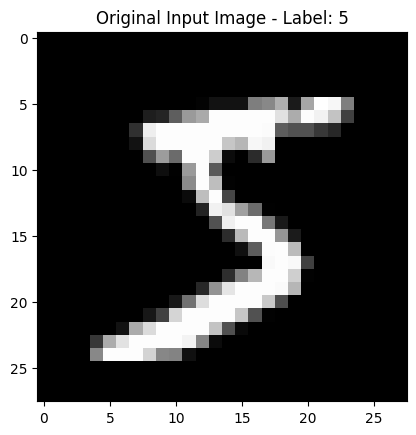

After Convolution:
 [[[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.71337858 ... 0.         0.         0.        ]
  [0.         0.         0.5298107  ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.23942662 ... 0.         0.         0.        ]
  [0.         0.         0.13551136 ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]]


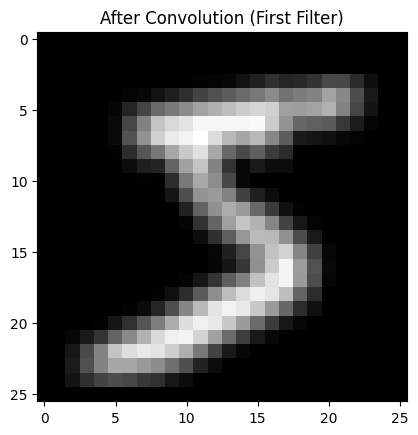

After Pooling:
 [[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
   0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
   0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
   0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
   0.00000000e+00 6.12626217e-02 1.56491607e-01 8.04496364e-01
   1.26732556e+00 1.28949083e+00 1.92947951e+00 1.08685807e+00
   0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 1.43990626e-01 1.76777945e+00
   3.15378287e+00 4.22533047e+00 4.87704522e+00 5.51330091e+00
   5.36181980e+00 4.17536893e+00 4.58645853e+00 1.99320491e+00
   0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 2.56947266e-01 3.78255642e+00
   6.04360952e+00 6.59750976e+00 6.38301993e+00 6.46863483e+00
   5.24202350e+00 2.66284380e+00 2.35141630e+00 7.03441957e-01
   0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 7.01220038e-02 2.23258739e+00
   4.28440008e+00 5.78977717e+00 4.30524718e+00 2.46546769e+00
   1.56430426e+00 0.000000

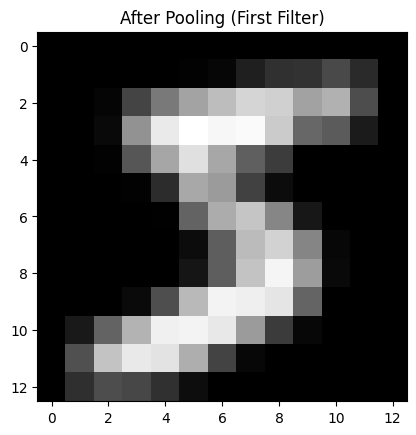

After Fully Connected Layer:
 [196.63942632 174.8406466  193.62075593 209.71033562 196.28965175
 198.92010995 189.69860775 208.09906154 203.2021283  208.21427123]
Final Output Vector (ReLU activated):
 [196.63942632 174.8406466  193.62075593 209.71033562 196.28965175
 198.92010995 189.69860775 208.09906154 203.2021283  208.21427123]


In [ ]:
import numpy as np
import csv
import matplotlib.pyplot as plt

# --------------------------
# 1. Load MNIST CSV
# --------------------------

def load_mnist_csv(path, limit=None):
    images, labels = [], []
    with open(path, 'r') as f:
        reader = csv.reader(f)
        next(reader)  
        for i, row in enumerate(reader):
            if limit and i >= limit:
                break
            labels.append(int(row[0]))
            images.append([int(pixel)/255.0 for pixel in row[1:]])
    return np.array(images), np.array(labels)


train_images, train_labels = load_mnist_csv("./data/mnist_train.csv", limit=1)

image = train_images[0].reshape(28,28)
plt.imshow(image, cmap='gray')
plt.title(f"Original Input Image - Label: {train_labels[0]}")
plt.show()

# --------------------------
# 2. Simple Convolution
# --------------------------

def convolutional_layers(image, filters):
    conv_out = []
    for f in filters:
        filter_size = f.shape[0]
        output_size = image.shape[0] - filter_size + 1
        conv = np.zeros((output_size, output_size))
        for i in range(output_size):
            for j in range(output_size):
                conv[i,j] = np.sum(image[i:i+filter_size, j:j+filter_size] * f)
        conv_out.append(conv)
    return np.array(conv_out)

# --------------------------
# 3. Simple Max Pooling
# --------------------------

def pooling_layer(feature_maps, pool_size=2, stride=2, mode='max'):
    pooled_out = []
    for fm in feature_maps:
        h, w = fm.shape
        out_h = (h - pool_size)//stride + 1
        out_w = (w - pool_size)//stride + 1
        pooled = np.zeros((out_h, out_w))
        for i in range(out_h):
            for j in range(out_w):
                window = fm[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
                if mode=='max':
                    pooled[i,j] = np.max(window)
                elif mode=='average':
                    pooled[i,j] = np.mean(window)
        pooled_out.append(pooled)
    return np.array(pooled_out)

# --------------------------
# 4. Fully Connected Layer
# --------------------------

def connected_layer(feature_maps, weights, bias, activation):
    # flatten
    x = feature_maps.flatten()
    z = np.dot(x, weights) + bias
    return activation(z)

# --------------------------
# 5. Forward Pass
# --------------------------

conv_filters_list = [np.random.rand(3,3), np.random.rand(3,3)]  # 2 filters
pool_size = 2
stride = 2
pool_mode = 'max'
fc_weights = np.random.rand(2*13*13, 10)  # 2 feature maps of 13x13 after pooling
fc_bias = np.random.rand(10)
activation_function = lambda x: np.maximum(0, x)  # ReLU

def CNN_from_scratch(input_image, conv_filters_list, pool_size, stride, pool_mode, fc_weights, fc_bias, activation_function):
    conv_out = convolutional_layers(input_image, conv_filters_list)
    print("After Convolution:\n", conv_out)
    plt.imshow(conv_out[0], cmap='gray')
    plt.title("After Convolution (First Filter)")
    plt.show()

    pooled_out = pooling_layer(conv_out, pool_size, stride, mode=pool_mode)
    print("After Pooling:\n", pooled_out)
    plt.imshow(pooled_out[0], cmap='gray')
    plt.title("After Pooling (First Filter)")
    plt.show()

    final_out = connected_layer(pooled_out, fc_weights, fc_bias, activation_function)
    print("After Fully Connected Layer:\n", final_out)
    return final_out

output = CNN_from_scratch(train_images[0].reshape(28,28),
                          conv_filters_list, pool_size, stride, pool_mode,
                          fc_weights, fc_bias, activation_function)

print("Final Output Vector (ReLU activated):\n", output)


___________________________________________________________

# **Conclusion:**

When we began, a single perceptron deciding on an umbrella felt like a small, almost trivial thing. But from that humble beginning, we've witnessed a profound emergence. We saw how layering these simple units creates a network capable of learning complex representations

This journey from a single if-else statement to a machine that can *see* is a testament to a powerful idea: **complex intelligence can arise from the thoughtful connection of simple parts.** It reminds us that sometimes, to understand the future, we must first be willing to build it ourselves, one line of code, one weight, one neuron at a time.

So in the end, If you’re working with images, videos, or any data that involves spatial relationships, CNNs are your best bet.